# TFM — Parque de Vehículos (DGT) vs. Renta de los Hogares (INE)
## Fase 2 — Análisis Exploratorio de Datos (EDA)

En esta fase **miramos los datos ya limpios para entenderlos**: cómo es el parque de
coches, qué valores raros quedan, qué variables se parecen entre sí y, sobre todo, si se
ven las relaciones que esperábamos entre la **renta del municipio** y el **tipo de coche**
(potencia, antigüedad, si es eléctrico, marca…).

Partimos de `dataset_procesado.parquet` (lo que dejó la Fase 1: **6.613.034 filas × 37
columnas**).

**Recorrido del notebook:** cargar los datos → foto general (perfilado) → arreglar unos
valores raros que dejamos pendientes → mirar variables de una en una → evolución por años →
variables de categorías → ver qué variables se parecen (correlaciones) → comparar renta con
tipo de coche (hipótesis H1–H5) → resumen.

---
## 0. Configuración e importaciones

Cargamos las librerías y preparamos el estilo de los gráficos.

In [1]:
%reload_ext autoreload
%autoreload 2

# ==============================================================================
# 1. LIBRERÍAS DE LA BIBLIOTECA ESTÁNDAR (System & File System)
# ==============================================================================
import sys
from pathlib import Path

# ==============================================================================
# 2. LIBRERÍAS DE TERCEROS (Data Science & Visualización)
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ==============================================================================
# 3. CONFIGURACIÓN DE RUTAS Y ENTORNO
# ==============================================================================
# Directorio de datos procesados (entrada de esta fase)
DIR_PROCESSED = Path("../data/processed")

# Añadir el directorio de codigo fuente ('src') al PATH para importar modulos locales
sys.path.append("../src")

# ==============================================================================
# 4. MÓDULOS PROPIOS (Trabajo de Fin de Máster - TFM)
# ==============================================================================
import tfm_limpieza  # Funciones de preprocesamiento y limpieza
import tfm_io        # Funciones de lectura/escritura (I/O)
import tfm_eda       # Funciones de analisis exploratorio (EDA)

# ==============================================================================
# 5. ESTÉTICA DE LAS VISUALIZACIONES
# ==============================================================================
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", None)

# Orden de los segmentos de renta, de menos a mas (para que los graficos salgan ordenados)
ORDEN_SEG = ["Muy baja", "Baja", "Media", "Alta", "Muy alta"]

---
## 1. Carga del dataset procesado

Leemos el archivo limpio que generó la Fase 1. La función `tfm_io.cargar_parquet` ya
comprueba que el archivo existe y avisa con un mensaje claro si no lo encuentra (en vez de
soltar un error largo).

In [2]:
df = tfm_io.cargar_parquet("dataset_procesado.parquet", DIR_PROCESSED)

Cargado exitosamente: 6,613,034 filas x 37 columnas


---
## 2. Foto general de los datos (perfilado)

Antes de analizar nada, sacamos una **foto rápida** del dataset: cuántas filas y columnas
tiene, de qué tipo es cada variable, cuántos huecos (nulos) hay, cuántas filas repetidas, y
los estadísticos básicos. Todo esto lo hace nuestra función `eda_preliminar`.

Le decimos que **no busque valores raros en `anio_matriculacion`**: un año concreto no es un
valor "atípico", es simplemente una fecha.

In [3]:
tfm_eda.eda_preliminar(df, cols_notin_outlier=["anio_matriculacion"])


>>> INFO ESTRUCTURAL
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6613034 entries, 0 to 6613033
Data columns (total 37 columns):
 #   Column                Dtype         
---  ------                -----         
 0   provincia             category      
 1   municipio             category      
 2   marca                 category      
 3   modelo                category      
 4   fec_prim_matr         datetime64[ns]
 5   procedencia           category      
 6   nuevo_usado           category      
 7   tipo_titular          category      
 8   num_titulares         Int8          
 9   cat_euro              category      
 10  renting               category      
 11  cilindrada            Int16         
 12  kw                    float32       
 13  consumo               float32       
 14  autonomia             float32       
 15  alimentacion          category      
 16  tipo_distintivo       category      
 17  emisiones_euro        category      
 18  emisiones_co2       

,provincia,municipio,marca,modelo,fec_prim_matr,procedencia,nuevo_usado,tipo_titular,num_titulares,cat_euro,renting,cilindrada,kw,consumo,autonomia,alimentacion,tipo_distintivo,emisiones_euro,emisiones_co2,carroceria,nombre_provincia,cod_municipio,nombre_municipio,renta_media_uc,renta_mediana_uc,renta_bruta_hogar,renta_bruta_persona,renta_neta_hogar,renta_neta_persona,tiene_municipio,anio_matriculacion,antiguedad,potencia_cv,tipo_combustible,es_electrificado,tipo_electrificacion,segmento_renta
5102955,28,28045,HYUNDAI,DESCONOCIDO,2012-02-22,IMPORT UE,NUEVO,PERSONA FISICA,1,M1,NO,1685,85.0,0.0,NaN,DESCONOCIDO,DISTINTIVO B,EURO 5,139.0,DESCONOCIDO,Madrid,28045,Colmenar Viejo,27567.0,24150.0,65814.0,22447.0,52003.0,17736.0,True,2012,14.102670,115.567696,DIESEL,False,COMBUSTION,Muy alta
4403345,28,28013,HYUNDAI,I30,2015-03-25,IMPORT UE,NUEVO,PERSONA FISICA,1,M1,NO,1582,81.0,0.0,0.0,MONOFUEL,DISTINTIVO B,EURO 5,114.0,AB,Madrid,28013,Aranjuez,21662.0,19250.0,49015.0,17173.0,40453.0,14173.0,True,2015,11.017112,110.129219,DIESEL,False,COMBUSTION,Media
4760958,28,28148,DACIA,DESCONOCIDO,2012-06-27,IMPORT NO UE,NUEVO,PERSONA FISICA,1,M1,NO,1461,55.0,0.0,NaN,MONOFUEL,DISTINTIVO B,EURO 5F,108.0,AA,Madrid,28148,Torrejón de Ardoz,22129.0,19950.0,50089.0,17473.0,41459.0,14463.0,True,2012,13.757700,74.779099,DIESEL,False,COMBUSTION,Media
4604607,28,28068,OPEL,DESCONOCIDO,2025-01-30,IMPORT UE,NUEVO,PERSONA FISICA,1,M1,NO,1199,100.0,0.0,0.0,MONOFUEL,ECO,EURO 6EA,124.0,AF,Madrid,28068,Guadarrama,24913.0,22050.0,55113.0,20395.0,44863.0,16602.0,True,2025,1.163587,135.961990,GASOLINA,True,HEV,Alta
1173645,08,NaN,PEUGEOT,DESCONOCIDO,2021-04-30,IMPORT UE,NUEVO,PERSONA FISICA,1,M1,NO,1199,96.0,0.0,0.0,MONOFUEL,DISTINTIVO C,EURO 6AM,135.0,AB,Barcelona,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,2021,4.917180,130.523514,GASOLINA,False,COMBUSTION,SIN DATO



>>> DIMENSIONES


'El conjunto de datos tiene 6,613,034 filas y 37 columnas.'


>>> VALORES NULOS (%)


...

segmento_renta
Muy alta    36.57
SIN DATO    16.79
Media       15.27
Alta        14.71
Baja         8.72
Muy baja     7.94
Name: proportion, dtype: float64


>>> DETECCIÓN DE POSIBLES OUTLIERS (MÉTODO IQR)


,Cantidad de Outliers,% del Total
emisiones_co2,605003,9.15
autonomia,427518,6.46
consumo,425140,6.43
renta_mediana_uc,401636,6.07
renta_neta_hogar,394995,5.97
renta_bruta_hogar,389761,5.89
cilindrada,288904,4.37
potencia_cv,233640,3.53
kw,233628,3.53
renta_media_uc,113102,1.71



>>> TENDENCIA CENTRAL Y DISPERSIÓN (NUMÉRICAS)


,count,mean,min,25%,50%,75%,max,std
fec_prim_matr,6613034,2019-04-03 02:42:57.077210880,2010-01-01 00:00:00,2015-10-02 00:00:00,2019-04-30 00:00:00,2023-06-20 00:00:00,2026-03-31 00:00:00,NaN
num_titulares,6613034.0,1.000525,1.0,1.0,1.0,1.0,3.0,0.023167
cilindrada,6613034.0,1483.098178,0.0,1199.0,1498.0,1796.0,12777.0,489.24311
kw,6613032.0,92.80658,0.0,72.0,85.0,110.0,999.98999,37.867699
consumo,6613032.0,10.690473,0.0,0.0,0.0,0.0,5027.0,41.723194
autonomia,5589124.0,1819.607422,0.0,0.0,0.0,0.0,935200.0,8400.647461
emisiones_co2,6445194.0,115.793961,0.0,106.0,119.0,133.0,999.999023,35.389999
renta_media_uc,5502832.0,25740.016112,14207.0,21168.0,23739.0,29129.0,49811.0,6365.124622
renta_mediana_uc,5502832.0,21656.36614,12250.0,18550.0,21350.0,23450.0,37450.0,4413.372369
renta_bruta_hogar,5502832.0,58795.218769,28157.0,45949.0,52807.0,64574.0,138851.0,19810.773353


> 🟢 ¿Qué estamos mirando en esta salida?
>
> - **Nulos**: huecos en los datos. Que `renta` y `municipio` tengan ~16,8% de huecos es
>   **normal y esperado**: en los pueblos de menos de 10.000 habitantes la DGT oculta el
>   municipio para proteger la privacidad, así que esos coches se quedan sin dato de renta.
> - **Outliers (valores atípicos)**: la función marca como "raras" las variables del motor
>   (`kw`, `cilindrada`, `potencia_cv`…). Eso es justo lo que vamos a revisar en el punto 3:
>   hay que separar los **errores disfrazados de número** de los **coches potentes de verdad**.

---
## 3. Arreglar valores raros que quedaron pendientes

En la Fase 1 dejamos a propósito varias cosas para resolver aquí, porque necesitábamos
*ver* los datos para decidir bien.

> 🟢  En la limpieza pensabamos en "tratar los nulos" = *rellenar o quitar huecos*. Aquí el
> problema es **el contrario**: hay celdas que **parecen un número normal pero en realidad
> significan "no lo sé"**. Por ejemplo, un sistema que no conoce la potencia de un coche
> escribe `999.99` (un número "de relleno", o *placeholder*), o escribe un `0`. Si los
> dejamos así, el sistema los tratará como potencias reales y nos **falseará las medias y
> los gráficos**.
>
> La solución es **convertir esos números-mentira en `NaN`**. `NaN` es la etiqueta oficial
> de pandas para decir "aquí no hay dato". Lo bueno: en las medias, gráficos, etc., pandas
> **ignora los `NaN`**. O sea, no estamos "metiendo huecos nuevos": estamos **marcando como
> hueco lo que ya era un dato falso**, para que no nos engañe.
>
> Y **no borramos la fila entera** porque el resto de esa fila (provincia, marca, año,
> renta…) sí es válido y útil. Solo "vaciamos" la celda concreta que estaba mal.

### 3.1. El valor de relleno `kw ≈ 999.99`

`999.99` es el número más grande que cabe en ese campo de la base de datos. No es una
potencia real: es lo que se escribe cuando **no se conoce** la potencia. Lo confirmamos
viendo qué coches lo llevan: si fuera real, serían 1 o 2 superdeportivos concretos; si es
relleno, aparecerán **marcas de lo más variado** (señal de que es ruido).

In [4]:
# Lo buscamos con un margen (en kw, el 999.99 no se guarda exacto por como funcionan los decimales)
mask_kw_placeholder = df["kw"].between(999, 1000).fillna(False)
print(f"Coches con kw de relleno (~999.99): {mask_kw_placeholder.sum():,} "
      f"({mask_kw_placeholder.mean()*100:.2f}%)")

# Si saliesen marcas muy variadas => es relleno, no un modelo real concreto
print("\nMarcas que llevan ese valor (si son muy variadas, es relleno):")
display(df.loc[mask_kw_placeholder, "marca"].value_counts().head(10))

Coches con kw de relleno (~999.99): 29 (0.00%)

Marcas que llevan ese valor (si son muy variadas, es relleno):


marca
FIAT                      21
AUDI                       3
ALFA ROMEO                 1
JEEP                       1
DESCONOCIDO                1
SMART                      1
OPEL                       1
ABARTH                     0
ASTON MARTIN               0
ALQUIBER QUALITY, S.A.     0
Name: count, dtype: int64

In [5]:
# Tratamiento: ese valor de relleno pasa a NaN ('no se conoce la potencia')
df.loc[mask_kw_placeholder, "kw"] = np.nan
df["kw"] = df["kw"].astype("float32")
print(f"Potencia (kw) maxima despues de quitar el relleno: {df['kw'].max():.2f} kW")

Potencia (kw) maxima despues de quitar el relleno: 998.00 kW


### 3.2. Los ceros en `cilindrada` y en `kw`

Un `0` no significa lo mismo según el coche:

- **`cilindrada = 0`**: en un **eléctrico** es correcto (no tiene motor de combustión, así
  que no tiene cilindrada). En un coche de **gasolina/diésel** es imposible → es un hueco
  disfrazado de cero.
- **`kw = 0`**: **nunca** es real (un coche matriculado siempre tiene potencia). Es un hueco
  en todos los casos.

Primero comprobamos el cruce con "¿es eléctrico?" para asegurarnos antes de tocar nada.

In [6]:
print(">>> cilindrada == 0, separado entre electricos y no electricos:")
display(df.loc[df["cilindrada"].eq(0).fillna(False)]
          .groupby("es_electrificado", observed=True).size())

print("\n>>> kw == 0, separado entre electricos y no electricos:")
display(df.loc[df["kw"].eq(0).fillna(False)]
          .groupby("es_electrificado", observed=True).size())

>>> cilindrada == 0, separado entre electricos y no electricos:


es_electrificado
False       138
True     207725
dtype: int64


>>> kw == 0, separado entre electricos y no electricos:


es_electrificado
False    13878
True      4438
dtype: int64

 > 🟢 Lo que confirma el cruce de arriba: casi todos los `cilindrada = 0` son **eléctricos** (ahí
> el 0 es correcto y lo dejamos). Solo unos cuantos son coches de combustión con cilindrada 0 →
> esos sí son huecos y los marcamos como `NaN`. En cambio, **todos** los `kw = 0` los
> marcamos como hueco, porque ningún coche tiene 0 de potencia.

In [7]:
# Creamos 'mascaras' (listas de Verdadero/Falso) para señalar las celdas a vaciar.
# El .fillna(False) evita un error cuando hay NaN dentro de la comparacion.
mask_cil_nulo = (df["cilindrada"].eq(0) & ~df["es_electrificado"]).fillna(False)
mask_kw_cero  = df["kw"].eq(0).fillna(False)

# cilindrada 0 en combustion -> NaN (hueco) ; cilindrada 0 en electrico -> se queda (es real)
df.loc[mask_cil_nulo, "cilindrada"] = pd.NA
# kw 0 -> NaN (imposible que un coche matriculado tenga 0 de potencia)
df.loc[mask_kw_cero, "kw"] = np.nan

# Volvemos a fijar el tipo y recalculamos la potencia en CV (depende de kw)
df["cilindrada"]  = df["cilindrada"].astype("Int16")
df["kw"]          = df["kw"].astype("float32")
df["potencia_cv"] = (df["kw"] * 1.35962).astype("float32")  # 1 kW = 1.35962 CV

print(f"Ceros de cilindrada (combustion) marcados como hueco: {mask_cil_nulo.sum():,}")
print(f"Ceros de kw marcados como hueco:                      {mask_kw_cero.sum():,}")
print("\nResumen de las variables del motor ya saneadas:")
display(df[["cilindrada", "kw", "potencia_cv"]].describe().round(2))

Ceros de cilindrada (combustion) marcados como hueco: 138
Ceros de kw marcados como hueco:                      18,316

Resumen de las variables del motor ya saneadas:


,cilindrada,kw,potencia_cv
count,6612896.0,6594687.00,6594687.00
mean,1483.13,93.06,126.53
std,489.2,37.55,51.06
min,0.0,0.01,0.01
25%,1199.0,72.00,97.89
50%,1498.0,85.00,115.57
75%,1796.0,110.00,149.56
max,12777.0,998.00,1356.90


> 🟢 Después de esto, las medias del motor ya son fiables: la potencia media queda en ~126 CV y
> la cilindrada media en ~1.480 cc, valores razonables para turismos. Los coches potentes
> **de verdad** se quedan (no son errores). Solo en el punto 3.3 quitaremos los valores
> **imposiblemente** altos.

### 3.3. ¿Y los valores altos que quedan? (p. ej. `998 kW`)

Los 998 kW son **~1.357 CV**. Ningún turismo de los que se venden de
forma normal llega a esa potencia, así que ese 998 parece seguir siendo ruido, no
un coche real.

Pero **el método correcto no es ir bajando el número a mano** (999 → 998 → 850 → …). Si
hacemos eso, tarde o temprano empezamos a borrar **coches potentes que sí existen** (por
ejemplo, un Tesla Model S Plaid ronda los 760 kW / 1.020 CV, y es real). Lo que se hace es
mirar **toda la cola alta de golpe** y fijar **un único tope razonable**, justificado por
lo que existe en el mercado.

> 🟢 Para distinguir relleno de coche real, mirando la cola alta:
>
> - Un **valor de relleno** aparece como un **"montón" de coches repetidos en un valor
>   exacto** (p. ej. 305 coches justo en 850,99). Eso no pasa con datos reales.
> - Los **coches reales** potentes se reparten en **muchos valores distintos**, con pocos
>   coches en cada uno.
>

In [8]:
# Diagnostico de la cola alta de potencia (no tocamos nada todavia, solo miramos)
print("Cuantos coches superan cada umbral de potencia:")
for u in [300, 400, 500, 600, 700, 800, 900]:
    n = (df["kw"] > u).sum()
    print(f"  kw > {u} kW (~{u*1.35962:.0f} CV): {n:,}")

print("\nValores de kw mas REPETIDOS por encima de 400 kW (un 'monton' = relleno):")
display(df.loc[df["kw"] > 400, "kw"].round().value_counts().head(15))

print("Marcas en la cola alta (kw > 400):")
display(df.loc[df["kw"] > 400, "marca"].value_counts().head(10))

Cuantos coches superan cada umbral de potencia:
  kw > 300 kW (~408 CV): 35,133
  kw > 400 kW (~544 CV): 7,129
  kw > 500 kW (~680 CV): 1,642
  kw > 600 kW (~816 CV): 685
  kw > 700 kW (~952 CV): 482
  kw > 800 kW (~1088 CV): 330
  kw > 900 kW (~1224 CV): 269

Valores de kw mas REPETIDOS por encima de 400 kW (un 'monton' = relleno):


kw
430.0    545
441.0    478
412.0    403
460.0    399
461.0    338
404.0    308
478.0    251
504.0    190
463.0    184
423.0    177
405.0    162
932.0    155
421.0    143
456.0    134
470.0    133
Name: count, dtype: int64

Marcas en la cola alta (kw > 400):


marca
DESCONOCIDO      1497
TESLA             939
BMW               792
PORSCHE           758
AUDI              685
FERRARI           533
MERCEDES-BENZ     501
BENTLEY           249
FIAT              144
FORD              126
Name: count, dtype: int64

> 🟢 Lo que cuenta el diagnóstico **con los datos** (y por qué el tope de 800 está bien elegido):
>
> - Las marcas de la cola alta son **deportivos de verdad**: Ferrari, Porsche, Bentley,
>   Mercedes-AMG, Tesla… Estas marcas **sí** fabrican coches de 400–600 kW. Por eso **no
>   bajamos más el tope**: si lo bajáramos a 400 o 500, estaríamos borrando coches reales.
> - Más arriba aparece un **"montón" sospechoso en torno a ~930 kW** (un valor exacto
>   repetido en muchos coches): eso es el patrón típico de un valor de relleno, no de coches
>   reales.
>
> Resultado: el tope de 800 kW **deja dentro a los deportivos reales** y **quita ese montón
> imposible** de la parte de arriba. Son solo ~330 coches sobre 6,6 millones, así que el
> efecto en las medias es mínimo; lo valioso es que la decisión queda justificada con datos.

In [9]:
# Tratamiento: fijamos UN tope razonable para turismos y lo que lo supere pasa a NaN.
# 800 kW (~1.090 CV) deja dentro los electricos muy potentes reales (Tesla Plaid ~760 kW)
# y descarta lo imposible. Podemos subir/bajar este numero segun veas en el diagnostico
# de arriba; ponerlo muy alto (p. ej. 9999) equivaldria a no quitar nada.
TOPE_KW = 800
n_tope = (df["kw"] > TOPE_KW).sum()
df.loc[df["kw"] > TOPE_KW, "kw"] = np.nan
df["kw"] = df["kw"].astype("float32")
df["potencia_cv"] = (df["kw"] * 1.35962).astype("float32")
print(f"Coches por encima de {TOPE_KW} kW marcados como hueco: {n_tope:,}")
print(f"Nueva potencia maxima: {df['kw'].max():.2f} kW "
      f"(~{df['kw'].max()*1.35962:.0f} CV)")

Coches por encima de 800 kW marcados como hueco: 330
Nueva potencia maxima: 800.00 kW (~1088 CV)


> 🟢 ¿Por qué un tope y no seguir bajando el número? El tope es **una sola decisión, explicable y
> defendible** ("por encima de ~800 kW no hay turismos de producción"), mientras que ir caso
> por caso es arbitrario y acabaríamos borrando coches reales.
>
> Y un apunte tranquilizador: tanto si ponemos el tope en 800 como si decidimos **no quitar
> nada**, el resultado del análisis **apenas cambia**. 
> Son unos cientos de coches sobre 6,6 millones, así que casi no mueven las medias. 

---
## 4. Análisis univariante (Mirar las variables de una en una)

Empezamos por lo más simple: **una variable cada vez**. Un histograma agrupa los coches por
rangos y nos enseña la *forma* de la variable: dónde se concentra la mayoría y si hay cola
hacia los valores altos. La **línea roja** marca la mediana (el valor central).

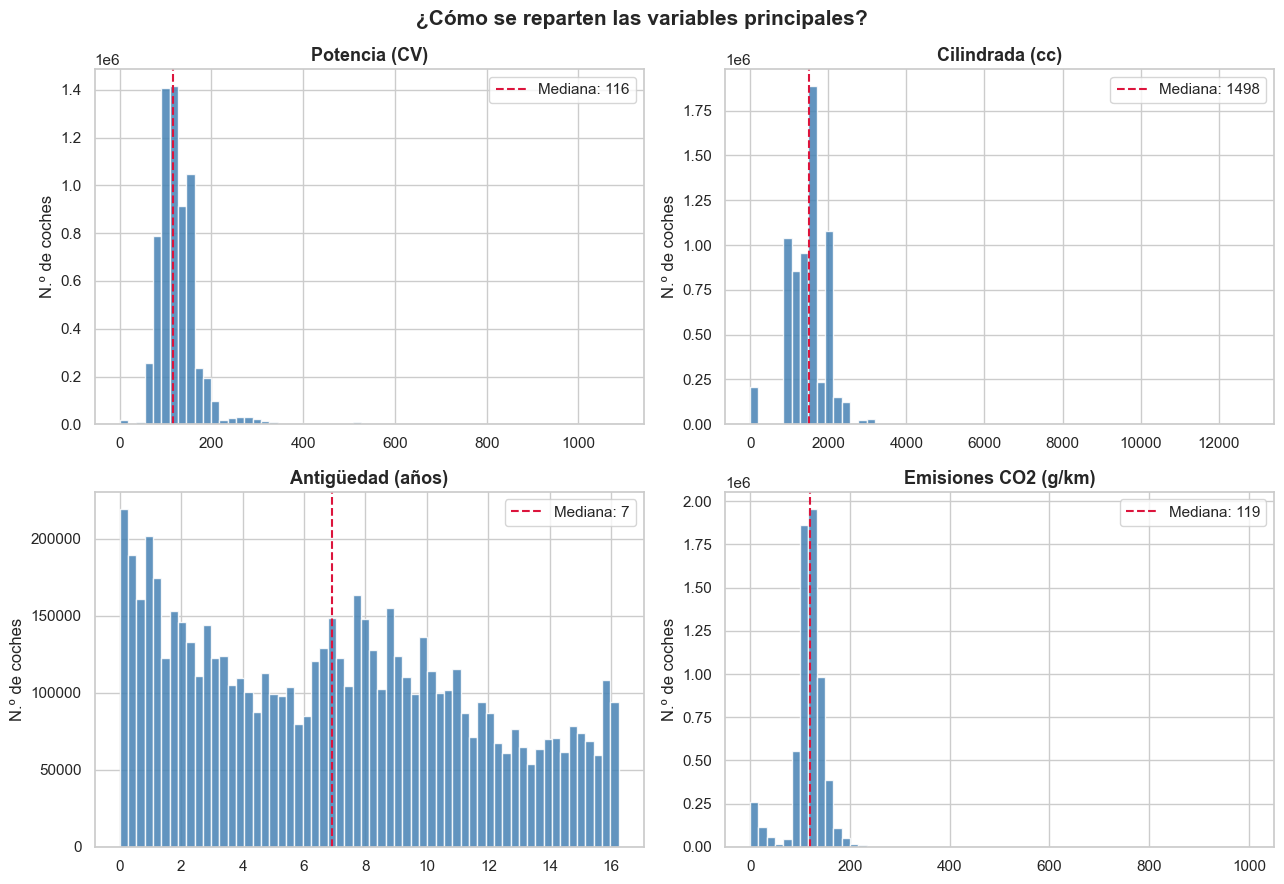

In [10]:
cols_hist = ["potencia_cv", "cilindrada", "antiguedad", "emisiones_co2"]
titulos   = ["Potencia (CV)", "Cilindrada (cc)", "Antigüedad (años)", "Emisiones CO2 (g/km)"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col, titulo in zip(axes.ravel(), cols_hist, titulos):
    datos = df[col].dropna().astype("float64")
    ax.hist(datos, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(datos.median(), color="crimson", linestyle="--", linewidth=1.5,
               label=f"Mediana: {datos.median():.0f}")
    ax.set_title(titulo)
    ax.set_ylabel("N.º de coches")
    ax.legend()
fig.suptitle("¿Cómo se reparten las variables principales?", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

> 🟢 **Interpretación de la Distribución de las Variables** 

> A partir de los cuatro gráficos generados, se pueden extraer las siguientes observaciones:

> * **Potencia y cilindrada:** La gran mayoría de los vehículos se concentra en valores bajos y medios, presentando una "cola" alargada hacia la derecha debido a un número reducido de coches con altas prestaciones. 
> Estadísticamente, este comportamiento define una distribución *asimétrica a la derecha*.
> * **Emisiones de $CO_2$:** Destaca un pico pronunciado en el valor cero, el cual corresponde de forma directa a la presencia de los vehículos puramente eléctricos, caracterizados por la ausencia de emisiones en el tubo de escape.
> * **Antigüedad:** Los datos muestran una mayor concentración de vehículos nuevos en el rango de 0 a 2 años (superando los 200.000 coches por año). A partir de los 3 años, la distribución decrece de forma paulatina con un perfil oscilante, manteniendo una mediana de antigüedad de 7 años.



---
## 5. Matriculaciones por año

Cuántos coches se matricularon por primera vez cada año. **2026 está incompleto** (los datos
llegan solo hasta marzo de 2026), por eso su barra sale en gris y no es comparable con las
demás.

> 🟢 ¿Para qué sirve este gráfico, si no habla de renta? Hace tres cosas útiles:
>
> 1. **Comprobación de cobertura:** confirma que los datos cubren de verdad 2010–2026, sin
>    años "agujero" ni saltos raros. Es un control de calidad antes de fiarnos del dataset.
> 2. **Contexto de la antigüedad (H2):** la antigüedad se calcula a partir de este año. Si
>    la mayoría de coches son recientes, el parque es "joven"; saberlo ayuda a interpretar H2.
> 3. **Base para el dashboard:** el año será uno de los filtros temporales del cuadro de
>    mando, así que conviene saber cómo se reparte.
>
> Aun así, el conteo "a secas" aporta poco al mensaje. Por eso justo debajo hacemos un
> segundo gráfico que **sí cuenta una historia**: cómo ha ido subiendo el coche electrificado
> año a año.

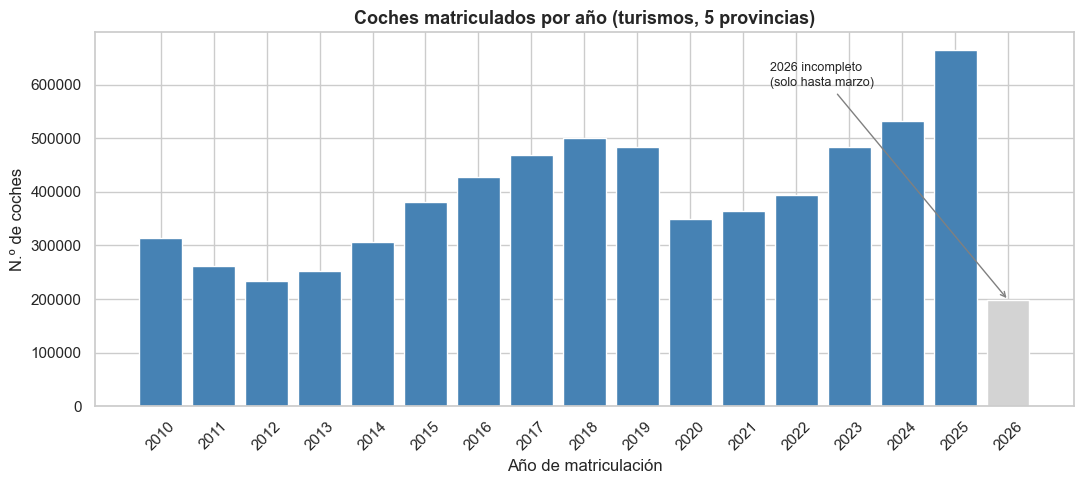

In [11]:
serie_anual = df["anio_matriculacion"].value_counts().sort_index()
anios = serie_anual.index.astype(int)              # años como enteros (sin decimales)

fig, ax = plt.subplots(figsize=(11, 5))
colores = ["steelblue" if a < 2026 else "lightgray" for a in anios]
barras = ax.bar(anios, serie_anual.values, color=colores, edgecolor="white")

ax.set_title("Coches matriculados por año (turismos, 5 provincias)")
ax.set_xlabel("Año de matriculación")
ax.set_ylabel("N.º de coches")
ax.set_xticks(anios)                                # una marca por año...
ax.set_xticklabels(anios, rotation=45)              # ...y en horizontal-girado, sin decimales
ax.annotate("2026 incompleto\n(solo hasta marzo)", xy=(2026, serie_anual.iloc[-1]),
            xytext=(2021.5, serie_anual.max()*0.9), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="gray"))
fig.tight_layout()
plt.show()

Y ahora el gráfico que de verdad cuenta algo: **qué porcentaje de los coches matriculados
cada año era electrificado**. Aquí se ve la transición del parque hacia el coche eléctrico
e híbrido, que enlaza directamente con la hipótesis H3.

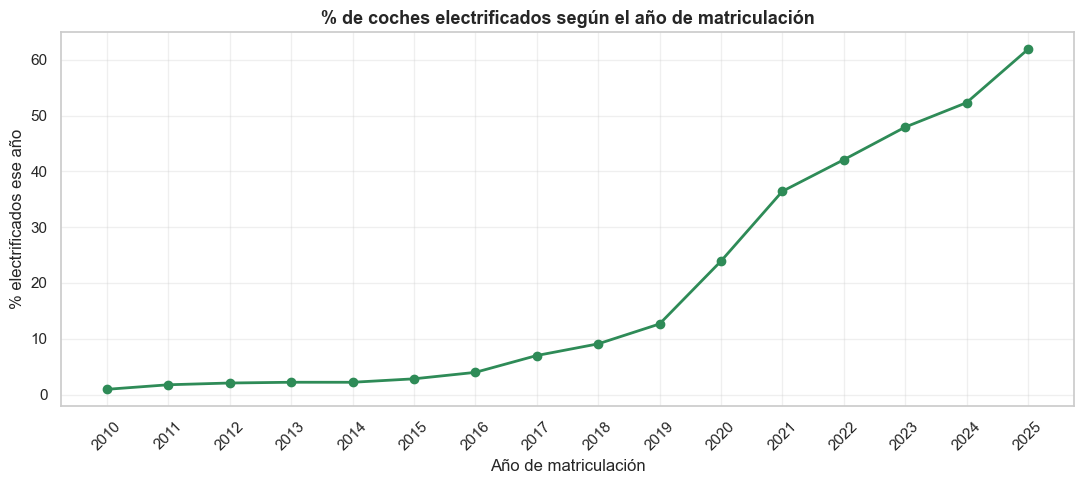

In [12]:
# % de electrificados segun el año de matriculacion (quitamos 2026 por incompleto)
elec_anio = (df.groupby("anio_matriculacion", observed=True)["es_electrificado"]
               .mean().mul(100))
elec_anio = elec_anio[elec_anio.index <= 2025]
anios2 = elec_anio.index.astype(int)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(anios2, elec_anio.values, marker="o", color="seagreen", linewidth=2)
ax.set_title("% de coches electrificados según el año de matriculación")
ax.set_xlabel("Año de matriculación")
ax.set_ylabel("% electrificados ese año")
ax.set_xticks(anios2)
ax.set_xticklabels(anios2, rotation=45)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

> 🟢 Esta curva sube de forma muy marcada en los últimos años: el coche electrificado pasa de ser
> casi testimonial al principio de la década a un porcentaje importante de las matriculaciones
> recientes. Es una forma visual de demostrar que el parque está cambiando, y conecta con H3
> (¿quién compra antes esos coches? los municipios de más renta).

---
## 6. Variables de Categorías (¿De qué está hecho el parque?)

Aquí no hay números, sino **etiquetas**: tipo de combustible, tipo de electrificación y
distintivo ambiental de la DGT. Vemos cuántos coches hay de cada tipo.

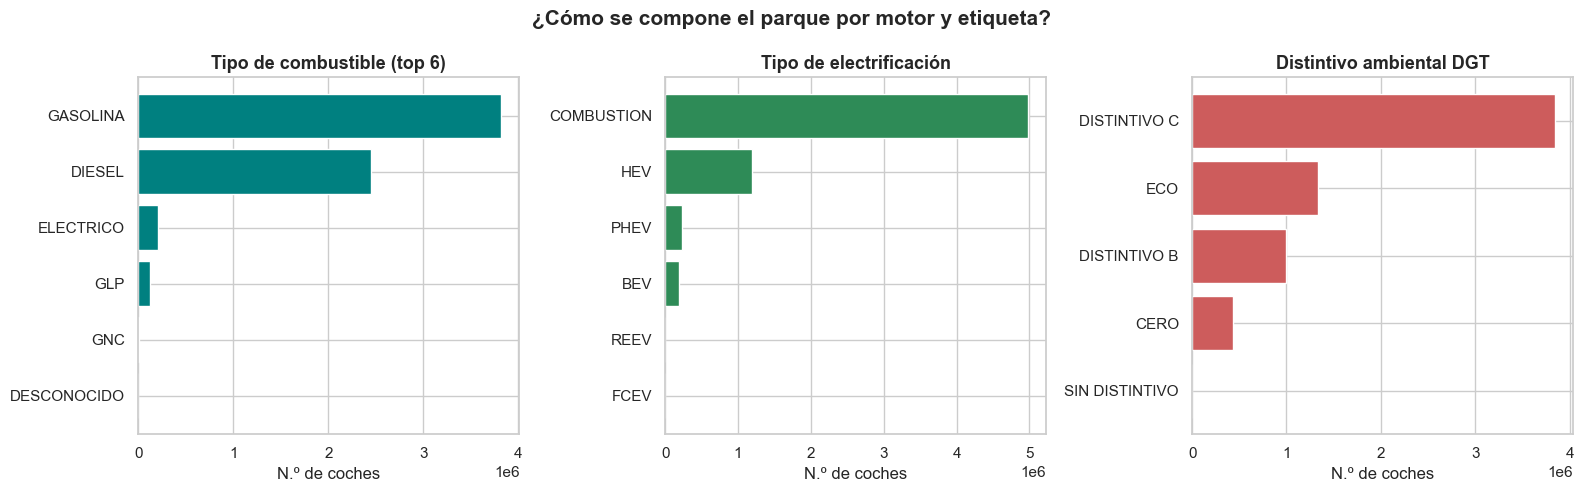

Coches electrificados (eléctrico, híbrido o enchufable): 24.6% del parque


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

comb = df["tipo_combustible"].value_counts().head(6)
axes[0].barh(comb.index[::-1].astype(str), comb.values[::-1], color="teal")
axes[0].set_title("Tipo de combustible (top 6)")
axes[0].set_xlabel("N.º de coches")

elec = df["tipo_electrificacion"].value_counts()
axes[1].barh(elec.index[::-1].astype(str), elec.values[::-1], color="seagreen")
axes[1].set_title("Tipo de electrificación")
axes[1].set_xlabel("N.º de coches")

dist = df["tipo_distintivo"].value_counts()
axes[2].barh(dist.index[::-1].astype(str), dist.values[::-1], color="indianred")
axes[2].set_title("Distintivo ambiental DGT")
axes[2].set_xlabel("N.º de coches")

fig.suptitle("¿Cómo se compone el parque por motor y etiqueta?", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"Coches electrificados (eléctrico, híbrido o enchufable): "
      f"{df['es_electrificado'].mean()*100:.1f}% del parque")

> 🟢 Estos gráficos son de barras horizontales: cuanto más larga la barra, más coches de ese
> tipo. Dominan gasolina y diésel; dentro de los electrificados, la mayoría son híbridos
> (HEV). En total, ~1 de cada 4 coches está electrificado de alguna forma.

---
## 7. Correlaciones (¿Qué variables se parecen entre sí?)

Una **correlación** mide si dos variables suben y bajan juntas, en una escala de -1 a 1:

- cerca de **1** → cuando una sube, la otra también (van muy de la mano);
- cerca de **0** → no tienen relación;
- cerca de **-1** → cuando una sube, la otra baja.

El mapa de calor de abajo pinta esas correlaciones: **rojo = se parecen mucho**, azul = se
comportan al revés, blanco = sin relación.

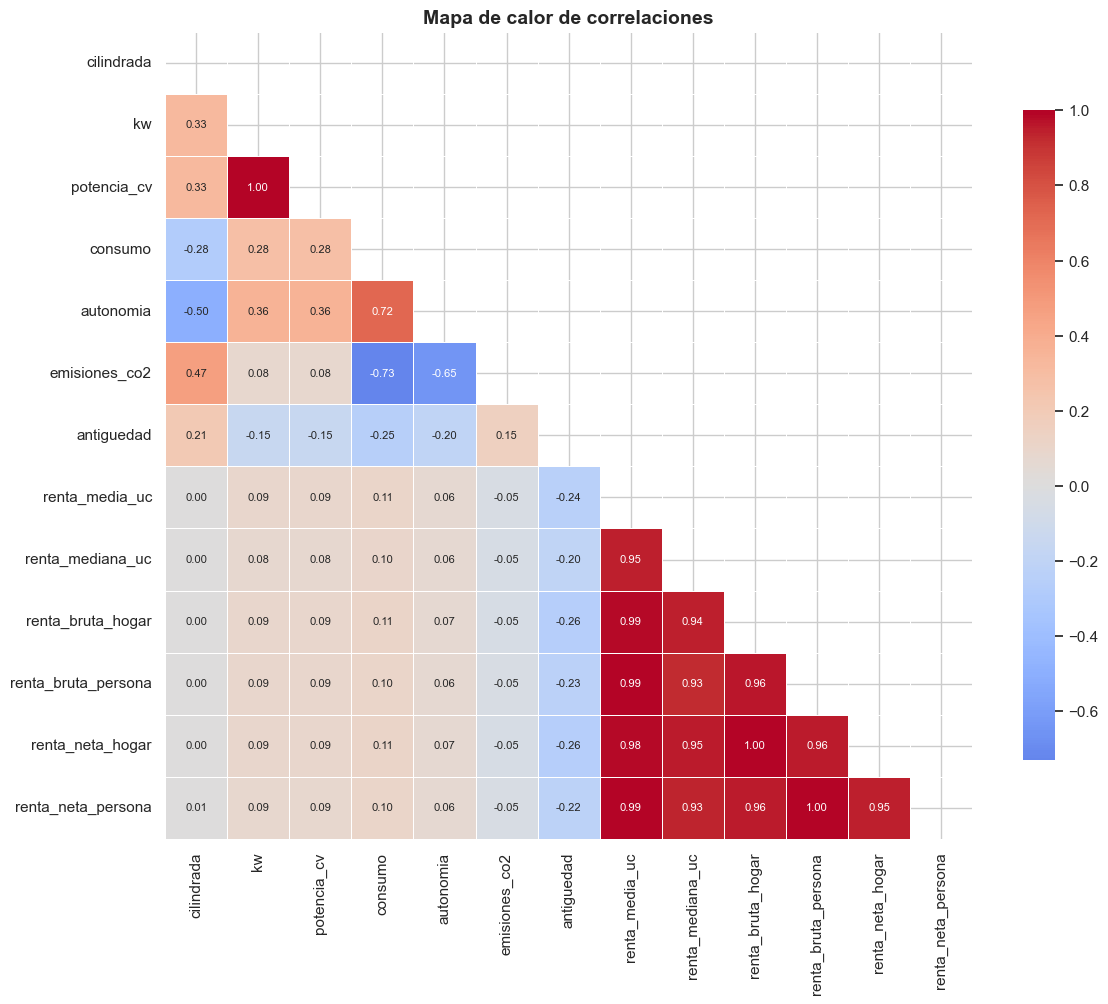

In [14]:
cols_corr = [
    "cilindrada", "kw", "potencia_cv", "consumo", "autonomia", "emisiones_co2",
    "antiguedad",
    "renta_media_uc", "renta_mediana_uc", "renta_bruta_hogar",
    "renta_bruta_persona", "renta_neta_hogar", "renta_neta_persona",
]
# .astype(float) convierte los enteros a decimales y respeta los huecos (NaN) al calcular
corr = df[cols_corr].astype("float64").corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # ocultamos la mitad de arriba (esta repetida)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8}, annot_kws={"size": 8})
plt.title("Mapa de calor de correlaciones", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

> 🟢 **¿Qué nos dice el mapa de calor de correlaciones?**
>
>Este gráfico nos sirve para ver la relación entre todas las variables numéricas. Cada casilla muestra un número que mide cómo se parecen dos variables: cuanto más cercano a 1 (color rojo) o a -1 (color azul), más relacionadas están. Se oculta la mitad de arriba porque sería un espejo de la de abajo y no aportaría información nueva.
>
>Al mirar los colores, descubrimos tres cosas muy claras sobre nuestros datos:
>
>* **Redundancia en las variables socioeconómicas:** En la esquina de abajo a la derecha hay un bloque completamente rojo con números de $0.93$ a $1.00$. Esto nos demuestra que la renta del hogar, la renta de la persona o la renta media al final nos están dando exactamente la misma información.
>* **Potencia por duplicado:** Como era de esperar, la potencia en `kw` y en `potencia_cv` tienen una relación perfecta de $1.00$, ya que son la misma medida expresada en unidades diferentes.
>* **La relación con el CO2:** Las casillas azules de arriba muestran que a mayor consumo o autonomía del coche, menores son las emisiones de $CO_2$ (números negativos como $-0.73$ o $-0.65$). Esto se explica por la mezcla de coches eléctricos (mucha autonomía y cero emisiones) frente a los tradicionales.


La **misma información, en forma de lista** (más fácil de leer que el grid): los pares de
variables con la correlación más alta, es decir, los que más se parecen entre sí.

In [15]:
# Convertimos la tabla de correlaciones en una lista ordenada de pares
solo_arriba = np.triu(np.ones(corr.shape), k=1).astype(bool)  # mitad superior, sin diagonal
pares = corr.where(solo_arriba).stack().sort_values(ascending=False)
pares.index = [f"{a}  ~  {b}" for a, b in pares.index]

print("Pares de variables que MAS se parecen (correlacion mas alta):")
display(pares.head(8).round(2).to_frame("correlacion"))

Pares de variables que MAS se parecen (correlacion mas alta):


,correlacion
kw ~ potencia_cv,1.00
renta_bruta_hogar ~ renta_neta_hogar,1.00
renta_bruta_persona ~ renta_neta_persona,1.00
renta_media_uc ~ renta_bruta_persona,0.99
renta_media_uc ~ renta_neta_persona,0.99
renta_media_uc ~ renta_bruta_hogar,0.99
renta_media_uc ~ renta_neta_hogar,0.98
renta_bruta_hogar ~ renta_bruta_persona,0.96


### ¿Qué nos dice este mapa?

Aparecen **dos grupos de variables muy parecidas entre sí** (todo en rojo intenso):

1. **Las del motor** (`kw`, `cilindrada`, `potencia_cv`): miden casi lo mismo. De hecho
   `potencia_cv` se calcula a partir de `kw`, así que su correlación es prácticamente 1.
2. **Las seis de renta** (media, mediana, por hogar, por persona, bruta, neta): todas miden
   "cuánto dinero hay en el municipio", así que van casi de la mano.

A que dos variables digan casi lo mismo se le llama **colinealidad**.

Otro detalle interesante: entre el bloque del **motor** y el bloque de la **renta** los
colores son pálidos (correlación baja). Es decir, **a nivel de coche individual la renta
casi no predice la potencia**. Esto encaja con que en H1 la diferencia de potencia entre
niveles de renta sea suave: el efecto aparece al comparar *municipios en promedio*, no
coche a coche.

> 🟢 **Por qué esto nos importa:**
>
> Si más adelante montásemos un modelo para *predecir* algo, meter dos variables que dicen
> lo mismo (p. ej. `kw` y `potencia_cv`) **lía al modelo** y no aporta información nueva. La
> recomendación es **quedarse con una de cada grupo** (por ejemplo `potencia_cv` para el
> motor y `renta_neta_persona` para la renta).
>
> ¿Y por qué entonces guardamos las 6 de renta en el dataset? Porque para *mirar* los datos
> y para el **dashboard** viene bien tenerlas todas (permiten distintas lecturas: por hogar
> o por persona, en bruto o neta). La colinealidad solo es un problema cuando *modelas*, no
> cuando *guardas* o *visualizas*.

---
## 8. Una comprobación final sobre la estructura de los datos

Antes de cerrar el EDA, una aclaración sobre el grupo de coches **sin municipio** (los de
poblaciones de menos de 10.000 habitantes, que el INE anonimiza). Conviene descartar que ese
grupo sea, en realidad, coches de renting "disfrazados", porque eso sesgaría el análisis
posterior.

> 🟢 La comparación de la renta con el tipo de coche (las hipótesis **H1–H5**) se hace en la
> **Fase 3** (`04_analisis_estadistico.ipynb`), agrupando por nivel de renta. Aquí en el EDA
> solo nos aseguramos de **entender y dejar limpios los datos** antes de responder nada: ese
> es el reparto de trabajo entre los dos notebooks (el 03 *explora*, el 04 *responde*).

**Comprobación rápida (lo apuntamos en la Fase 1):** los coches "sin municipio" **no** son
lo mismo que el renting. Si lo fueran, la columna *sin_municipio* tendría muchísimo más
renting que la de *con_municipio*. Veamos que el reparto es parecido en ambas:

In [16]:
ct = pd.crosstab(df["renting"], df["tiene_municipio"], normalize="columns").mul(100).round(1)
ct.columns = ["sin_municipio (%)", "con_municipio (%)"]
display(ct)

,sin_municipio (%),con_municipio (%)
renting,,
DESCONOCIDO,1.2,1.8
NO,81.1,87.1
SI,17.7,11.1


---
## Resumen de la Fase 2 (EDA)

**Lo que hemos arreglado aquí** (estaba pendiente del ETL): los valores de relleno
`kw ≈ 999.99`, los ceros imposibles de `kw` y `cilindrada`, y los valores de potencia
imposiblemente altos (por encima de ~800 kW) los hemos marcado como huecos (`NaN`) para que
no falseen las medias. Los coches potentes reales se mantienen.

**Lo que hemos aprendido sobre los datos:**

- Tras la limpieza, las distribuciones de potencia, cilindrada y antigüedad ya son razonables.
- El parque se renueva con fuerza en los últimos años y la electrificación crece con claridad.
- Hay **colinealidad**: dos grupos de variables que dicen casi lo mismo (las del motor —`kw`,
  `cilindrada`, `potencia_cv`— y las seis de renta). Al modelar conviene quedarse con una de
  cada grupo.
- El grupo "sin municipio" **no** es un proxy de renting, así que excluirlo del análisis de
  renta no introduce ese sesgo.

**Siguiente paso — Fase 3 (`04_analisis_estadistico.ipynb`):** responder a las hipótesis
H1–H5 comparando las métricas del coche por nivel de renta, y preparar las tablas agregadas
y ligeras para el dashboard de Power BI.